In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

from core.entities.constants import Paths as p
from infrastructure.utils.plotting import draw_points

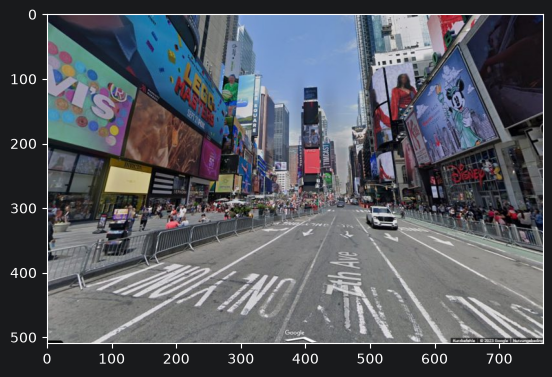

In [2]:
street_img_path = p.IMAGE_ASSETS / "street.jpg"
street_img = cv2.imread(street_img_path, cv2.IMREAD_COLOR_RGB)
plt.figure()
plt.imshow(street_img)

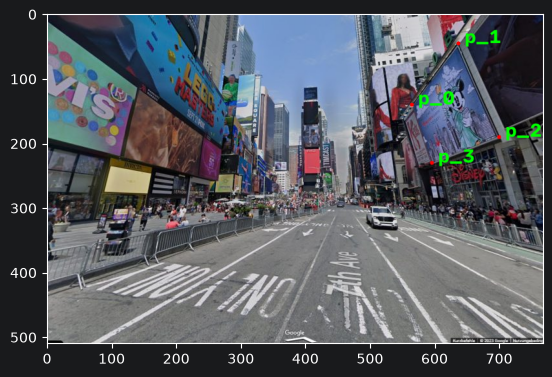

In [3]:
p1 = np.array([[565, 140],
               [637, 45],
               [700, 190],
               [596, 230]], dtype=np.float32)

pointed = draw_points(street_img, p1)
plt.figure()
plt.imshow(pointed)

In [4]:
h = int(np.linalg.norm(p1[0] - p1[3]))
w = int(np.linalg.norm(p1[0] - p1[1]))
print(f"h: {h}, w: {w}")

h: 95, w: 119


In [5]:
p2 = np.array([[0, 0],
               [w, 0],
               [w, h],
               [0, h]], dtype=np.float32)

In [6]:
T = cv2.getPerspectiveTransform(p1, p2)
T

array([[-6.87916209e-01,  2.36948916e-01,  3.55499810e+02],
       [-3.74105221e-01, -2.83532378e-01,  2.51063983e+02],
       [-2.56208808e-03,  5.92688848e-04,  1.00000000e+00]])

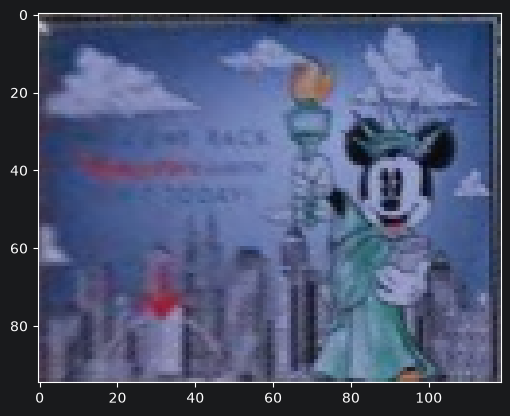

In [9]:
warped_img = cv2.warpPerspective(street_img, T, (w, h))
plt.figure()
plt.imshow(warped_img)